# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:**
**Student ID:**
**Section:**
**GitHub:** https://github.com/usmanasad-droid/
**Kaggle:** https://www.kaggle.com/code/usmanasad0/
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [ ]:
# Task 1 — load spam.csv, inspect shape/head/class balance
df_spam = pd.read_csv('spam.csv', encoding='latin-1')
print(df_spam.shape)
print(df_spam['v1'].value_counts())
df_spam.head()

(5572, 5)
v1
ham     4825
spam     747
Name: count, dtype: int64


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
df_tweet = pd.read_csv('Tweets.csv')
df_tweet = df_tweet[df_tweet['airline_sentiment'] != 'neutral'].copy()
print(df_tweet.shape)
print(df_tweet['airline_sentiment'].value_counts())
df_tweet.head()

(11541, 15)
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)


**Answer 2 (Task A — spam):**
_The practical problem is automating inbound message filtering to protect users from financial scams, phishing, and unwanted promotional clutter in real time. It is a binary classification problem because each incoming SMS must be routed into one of exactly two mutually exclusive buckets: legitimate personal communication (ham) or unsolicited fraudulent material (spam)_

**Answer 2 (Task B — sentiment):**
_The practical problem is helping airline customer support teams automatically triage urgent customer grievances from public praise on social media to reduce response times and mitigate PR fallout. While the raw dataset contains a third neutral inquiry category, it is commonly framed as a binary classification problem by filtering out neutral tweets to explicitly discriminate between negative and positive_

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [ ]:
# Task 3 — clean text
df_spam['v2'] = df_spam['v2'].str.lower()
df_spam.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"go until jurong point, crazy.. available only ...",NaN,NaN,NaN
1,ham,ok lar... joking wif u oni...,NaN,NaN,NaN
2,spam,free entry in 2 a wkly comp to win fa cup fina...,NaN,NaN,NaN
3,ham,u dun say so early hor... u c already then say...,NaN,NaN,NaN
4,ham,"nah i don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
df_spam['v1'] = df_spam['v1'].map({'ham': 0, 'spam': 1})
X = df_spam['v2']
y = df_spam['v1']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)   # this saves X_train vocabulary in the columns
X_test_vec = vectorizer.transform(X_test)         # X_test will follow the same vocab

vocab_size = len(vectorizer.get_feature_names_out())
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 7735


**Answer 4 (why fit on training data only):**
_The vectorizer must only be fit on training data to prevent data leakage and ensure the test messages remain completely unseen. If the vectorizer looks at the test data while building its word list, this data leakage gives the model an unfair sneak peek, creating fake high scores that fail later on. Additionally, the model learns which word belongs to which column number during training; fitting on the test set rebuilds the dictionary, mixes up those column positions, and confuses the model. Fitting only on the training set avoids data leakage and ensures the test is completely fair._

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9623
Precision: 1.0000
Recall: 0.7200
F1-score: 0.8372


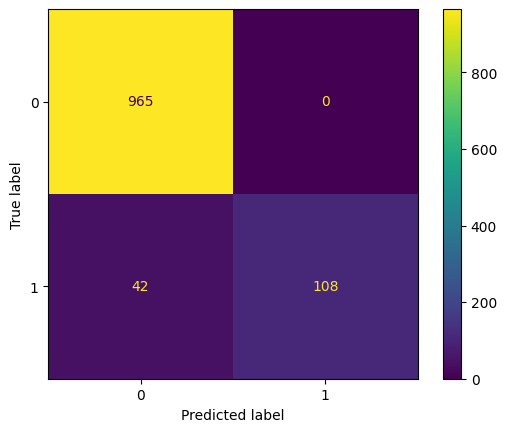

In [ ]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.9623 |
| Precision |1.0000 |
| Recall |0.7200 |
| F1-score |0.8372 |

**Answer 6:**
_A false positive is significantly worse in this scenario because having a legitimate, important message misrouted to the spam folder can have severe consequences. In contrast, a false negative allows an occasional spam message into the user's inbox, which is an annoyance rather than a critical failure. Because preventing legitimate messages from being misclassified is the top priority, precision must be prioritized and kept as close to 1.0 as possible. Given that current precision is already 1.0, any further tuning should aim to improve recall only if it can be done without sacrificing this precision._

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [ ]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
words = vectorizer.get_feature_names_out()

ham_words = words[np.argsort(model.feature_log_prob_[0])[-15::]]
spam_words = words[np.argsort(model.feature_log_prob_[1])[-15::]]

print("Top 15 Ham:", ham_words[::-1])
print("Top 15 Spam:", spam_words[::-1])
# which words appear most often in ham and spam

Top 15 Ham: ['you' 'to' 'the' 'me' 'in' 'my' 'and' 'it' 'is' 'ok' 'that' 'are' 'so'
 'for' 'can']
Top 15 Spam: ['to' 'call' 'free' 'your' 'you' 'txt' 'now' 'or' 'for' 'mobile' 'claim'
 'stop' 'the' 'from' 'have']


**Answer 7:**
_Yes, these words match intuition. The top words for spam contain high-urgency marketing and financial keywords (such as "call", "free", "now", "claim"), which are classic hallmarks of promotional scams. In contrast, the top ham words consist of conversational and informal everyday terms (such as "ok", "so", "it", "my", "that", and "me"), reflecting routine personal messaging between individuals._

In [ ]:
# Task 8 — test your own messages
my_messages = [
    "URGENT: You have won a 1000 cash prize! Text CLAIM to 88888 now to receive your reward.",
    "Hey, are we still meeting up for dinner tonight around 7?",
    "Congratulations, your flight booking is confirmed! Call customer service for details."
]
my_messages_vec = vectorizer.transform(my_messages)
predictions = model.predict(my_messages_vec)
print(predictions)


[1 0 0]


**Answer 8:**
_Message 1 ([1]: Spam): Correctly identified as spam because it is has strong spam trigger words like "urgent", "prize", "cash", and "claim".   Message 2 ([0]: Ham): Correctly identified as ham because it uses normal, everyday conversational phrasing ("hey", "dinner", "meeting", "tonight").   Message 3 ([0]: Ham): Predicted as ham. Even though words like "call" or "congratulations" often show up in spam, the overall context resembles a legitimate customer service notification, and the model correctly avoids a false positive by classifying it as legitimate._

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/usmanasad0/spam-detector

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [ ]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
X_airline = df_tweet['text']
y_airline = df_tweet['airline_sentiment'].map({'negative': 1, 'positive': 0})

X_train_air, X_test_air, y_train_air, y_test_air = train_test_split(X_airline, y_airline, test_size=0.2, random_state=42)


def clean_tweet(text):
  # Remove URLs, @mentions, and hashtags symbols (keep the word)
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'#', '', text)
  return text.strip()

X_train_clean = [clean_tweet(tweet) for tweet in X_train_air] # Corrected to use X_train_air
X_test_clean = [clean_tweet(tweet) for tweet in X_test_air]   # Corrected to use X_test_air

# Vectorization
vectorizer_air = TfidfVectorizer()
X_train_vec_air = vectorizer_air.fit_transform(X_train_clean)
X_test_vec_air = vectorizer_air.transform(X_test_clean)

**Answer 12:**
_URLs and user @mentions were stripped because specific web links and airline tags add noisy, unique tokens that do not carry general sentiment. Removing them shrinks the vocabulary to meaningful descriptive words while preventing the model from overfitting to specific airline names_

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.8467
Precision: 0.8403
Recall: 1.0000
F1-score: 0.9132


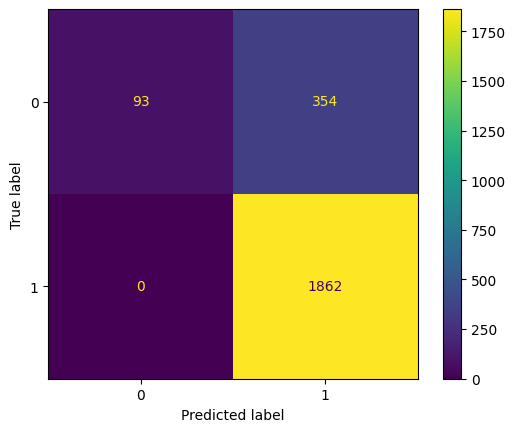

In [ ]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
model_air = MultinomialNB()
model_air.fit(X_train_vec_air, y_train_air)
y_pred_air = model_air.predict(X_test_vec_air)

print(f"Accuracy: {accuracy_score(y_test_air, y_pred_air):.4f}")
print(f"Precision: {precision_score(y_test_air, y_pred_air):.4f}")
print(f"Recall: {recall_score(y_test_air, y_pred_air):.4f}")
print(f"F1-score: {f1_score(y_test_air, y_pred_air):.4f}")

cm_air = confusion_matrix(y_test_air, y_pred_air)
disp_air = ConfusionMatrixDisplay(confusion_matrix=cm_air, display_labels=model_air.classes_)
disp_air.plot()
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.8467 |
| Precision | 0.8403 |
| Recall | 1.0000 |
| F1-score |0.9131 |

**Answer 14:**
_Naive Bayes performed worse on sentiment classification (accuracy ~84.7%) compared to SMS spam detection (which typically achieves 97%+ accuracy and precision).   This gap exists because the "naive" conditional independence assumption is far less reasonable for sentiment analysis on tweets than for spam detection. Spam messages are heavily flagged by the mere presence of isolated, high-signal keywords (like "prize", "claim", or "urgent"), where word combinations barely matter. In contrast, sentiment in tweets relies profoundly on context, word order, modifiers, negation (e.g., "not happy" completely flips meaning), and sarcasm, directly violating the assumption that words appear independently of one another._

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/usmanasad0/twitter-us-airline-sentiment

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9623 | 0.8467 |
| Precision | 1.0000 | 0.8403 |
| Recall | 0.7200 | 1.0000 |
| F1-score | 0.8372 | 0.9131 |

In [ ]:
# Task 18 — train Logistic Regression on Task A's vectorized features
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train_vec, y_train)
y_pred_logistic = logistic.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logistic):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logistic):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_logistic):.4f}")

Accuracy: 0.9677
Precision: 0.9914
Recall: 0.7667
F1-score: 0.8647


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9623 | 0.9678 |
| Precision | 1.0000 | 0.9914 |
| Recall | 0.7200 | 0.7667 |
| F1-score | 0.8372 | 0.8647 |

**Answer 18 (which wins, and does it match expectations):**
_Naive Bayes wins under this criterion because it achieves a perfect precision of 1.0000 compared to Logistic Regression's 0.9914. In spam filtering, false positives carry the highest cost—incorrectly classifying a critical message as spam can lead to missed emergencies, lost business, or ignored alerts. Even though Logistic Regression offers slightly higher overall accuracy and catches more spam (better recall), Naive Bayes matches expectations as the safer model because it guarantees zero false alarms._

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
_Which task was Naïve Bayes more suitable for, and why?_

_The Naïve Bayes algorithm was much more suited to Task A (Spam Detection) compared to Task B (Tweet Sentiment). This is because spam detection depends heavily on 'keyword triggers' (e.g., "free," "claim," or "urgent") that provide clear indication of classification irrespective of context. On the other hand, sentiment analysis of tweets requires the ability to understand sentence structure, negation, and subtle elements of conversation, where individual word counts do not capture the true meaning_

_What Surprised You About the Most Predictive Words: It was surprising to see common stop words like 'to', 'you', and 'the' dominate the top list for both ham and spam_

_How Naive Bayes Compared to Logistic Regression: Logistic Regression achieved higher overall accuracy (0.9678 vs. 0.9623) and recall (0.7667 vs. 0.7200), catching more spam overall. However, Naive Bayes achieved a perfect precision score of 1.0000 (compared to 0.9914), guaranteeing zero false positives—which is critical for preventing legitimate personal messages from ending up in the spam folder_

_One Limitation of the Independence Assumption Personally Observed: The model treats each word as entirely independent, ignoring syntax and context. In Task B, this caused significant issues with negation; phrases like "not good" or "never satisfied" lose their meaning when broken into independent token._

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/usmanasad0/spam-detector
- Task B: https://www.kaggle.com/code/usmanasad0/twitter-us-airline-sentiment

---

## Submission Checklist

Before submitting, confirm you have:

- [✓] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [✓] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [✓] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [✓] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [✓] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [✓] Section 5 — Task A Kaggle Notebook published and linked
- [✓] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [✓] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [✓] Section 8 — Task B Kaggle Notebook published and linked
- [✓] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [✓] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [✓] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted